## Install Ultralytics

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

# Libraries

In [ ]:
import os
from pathlib import Path
import zipfile
import random
import shutil
import logging
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
import logging
import sys

# Set up logging
logger = logging.getLogger()  # root logger
logger.setLevel(logging.INFO)

# Remove existing handlers
if logger.hasHandlers():
    logger.handlers.clear()

# Create StreamHandler to output to stdout (Colab cell)
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

# Optional: Also log to a file
log_file_path = "/content/drive/MyDrive/EnigmaAI_temp/combined_dataset_process.log"
file_handler = logging.FileHandler(log_file_path)
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

logger.info("Logging setup complete.")


2025-05-28 06:17:26,089 - INFO - Logging setup complete.


In [ ]:
BASE_GDRIVE_DIR = Path("/content/drive/MyDrive/EnigmaAI_temp/datasets")
combined_dataset_dir = Path("/content/drive/MyDrive/EnigmaAI_temp/combined_dataset")
temp_dir = Path("/content/temp")

# Create directories
combined_dataset_dir.mkdir(parents=True, exist_ok=True)
temp_dir.mkdir(parents=True, exist_ok=True)

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

# Define additional datasets
additional_datasets = {
    'hole': BASE_GDRIVE_DIR / "Pothole.v1-raw.yolov11.zip",
    'bottle': BASE_GDRIVE_DIR / "plaskat.v2i.yolov11.zip",
    'rock': BASE_GDRIVE_DIR / "rock detection.v2i.yolov11.zip",
    'stairs': BASE_GDRIVE_DIR / "stair-in-school.v3i.yolov11.zip"
}

# Class mappings: original class index -> base dataset class index
class_mappings = {
    'hole': {0: 0},  # 'pothole' -> 'hole' (0)
    'bottle': {0: 3, 1: 3, 2: 3},  # 'Deformed Plastic', 'Plastic', 'deformed plastic' -> 'bottle' (3)
    'rock': {0: 4},  # 'stone' -> 'rock' (4)
    'stairs': {0: 2}  # 'stair' -> 'stairs' (2)
}

In [ ]:
base_zip = BASE_GDRIVE_DIR / "base_dataset.zip"
base_extract_dir = temp_dir / "base"
combined_train_dir = combined_dataset_dir / "train"
combined_val_dir = combined_dataset_dir / "val"

# Create directories
for dir_path in [combined_train_dir / "images", combined_train_dir / "labels",
                 combined_val_dir / "images", combined_val_dir / "labels"]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Extract base dataset
with zipfile.ZipFile(base_zip, 'r') as zip_ref:
    zip_ref.extractall(base_extract_dir)

# Get images with corresponding labels
images_dir = base_extract_dir / "images"
labels_dir = base_extract_dir / "labels"
image_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
valid_images = [img for img in image_files if os.path.exists(labels_dir / img.replace('.jpg', '.txt'))]

logger.info(f"Base dataset: {len(valid_images)} images with labels out of {len(image_files)} total images")

# Split into train and val (80% train, 20% val)
random.seed(42)  # For reproducibility
random.shuffle(valid_images)
split_idx = int(0.8 * len(valid_images))
train_images = valid_images[:split_idx]
val_images = valid_images[split_idx:]

# Copy to combined dataset
for img in train_images:
    shutil.copy(images_dir / img, combined_train_dir / "images" / img)
    shutil.copy(labels_dir / img.replace('.jpg', '.txt'), combined_train_dir / "labels" / img.replace('.jpg', '.txt'))

for img in val_images:
    shutil.copy(images_dir / img, combined_val_dir / "images" / img)
    shutil.copy(labels_dir / img.replace('.jpg', '.txt'), combined_val_dir / "labels" / img.replace('.jpg', '.txt'))

logger.info(f"Base dataset: {len(train_images)} images to train, {len(val_images)} to val")

2025-05-28 02:14:28,215 - INFO - Base dataset: 1878 images with labels out of 1878 total images
2025-05-28 02:14:49,848 - INFO - Base dataset: 1502 images to train, 376 to val


In [ ]:
def process_additional_dataset(dataset_name, zip_path, class_mapping):
    extract_dir = temp_dir / dataset_name
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    for split in ['train', 'valid']:
        images_dir = extract_dir / split / "images"
        labels_dir = extract_dir / split / "labels"
        if not images_dir.exists():
            continue
        image_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
        for img in image_files:
            label_file = img.replace('.jpg', '.txt')
            if os.path.exists(labels_dir / label_file):
                # Remap labels
                with open(labels_dir / label_file, 'r') as f:
                    lines = f.readlines()
                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        original_class = int(parts[0])
                        if original_class in class_mapping:
                            new_class = class_mapping[original_class]
                            new_line = f"{new_class} {' '.join(parts[1:])}\n"
                            new_lines.append(new_line)
                if new_lines:  # Only include images with valid labels after remapping
                    temp_label_path = extract_dir / "temp_labels" / label_file
                    temp_label_path.parent.mkdir(parents=True, exist_ok=True)
                    with open(temp_label_path, 'w') as f:
                        f.writelines(new_lines)
                    # Copy to combined dataset
                    target_dir = combined_dataset_dir / ("train" if split == "train" else "val")
                    shutil.copy(images_dir / img, target_dir / "images" / img)
                    shutil.copy(temp_label_path, target_dir / "labels" / label_file)

    logger.info(f"Processed {dataset_name}: added to train and val")

In [ ]:
for dataset_name, zip_path in additional_datasets.items():
    class_mapping = class_mappings[dataset_name]
    process_additional_dataset(dataset_name, zip_path, class_mapping)

2025-05-28 02:15:01,304 - INFO - Processed hole: added to train and val
2025-05-28 02:15:08,675 - INFO - Processed bottle: added to train and val
2025-05-28 02:16:40,883 - INFO - Processed rock: added to train and val
2025-05-28 02:16:45,904 - INFO - Processed stairs: added to train and val


In [ ]:
data_yaml_content = """
train: train/images
val: val/images
nc: 5
names: ['hole', 'pole', 'stairs', 'bottle', 'rock']
"""

with open(combined_dataset_dir / "data.yaml", 'w') as f:
    f.write(data_yaml_content.strip())

logger.info("Created data.yaml for combined dataset")

2025-05-28 02:16:45,913 - INFO - Created data.yaml for combined dataset


In [ ]:
for split in ['train', 'val']:
    images_dir = combined_dataset_dir / split / "images"
    labels_dir = combined_dataset_dir / split / "labels"
    image_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
    for img in image_files:
        label_file = img.replace('.jpg', '.txt')
        if not os.path.exists(labels_dir / label_file):
            os.remove(images_dir / img)
            logger.warning(f"Removed {img} from {split} as it has no label")
    logger.info(f"Validated {split}: {len(image_files)} images remain")

2025-05-28 02:16:47,317 - INFO - Validated train: 9136 images remain
2025-05-28 02:16:47,468 - INFO - Validated val: 797 images remain


2025-05-28 02:16:47,586 - INFO - Total train images: 9136
2025-05-28 02:16:47,587 - INFO - Total val images: 797
2025-05-28 02:18:11,912 - INFO - Train class counts:
2025-05-28 02:18:11,913 - INFO - Class 1 (pole): 602
2025-05-28 02:18:11,914 - INFO - Class 2 (stairs): 376
2025-05-28 02:18:11,915 - INFO - Class 3 (bottle): 507
2025-05-28 02:18:11,915 - INFO - Class 0 (hole): 1308
2025-05-28 02:18:11,916 - INFO - Class 4 (rock): 74932
2025-05-28 02:18:11,916 - INFO - Val class counts:
2025-05-28 02:18:11,917 - INFO - Class 4 (rock): 2573
2025-05-28 02:18:11,917 - INFO - Class 1 (pole): 213
2025-05-28 02:18:11,918 - INFO - Class 3 (bottle): 81
2025-05-28 02:18:11,918 - INFO - Class 2 (stairs): 47
2025-05-28 02:18:11,919 - INFO - Class 0 (hole): 338
2025-05-28 02:18:12,161 - INFO - Class distribution saved to combined_dataset/class_distribution.png


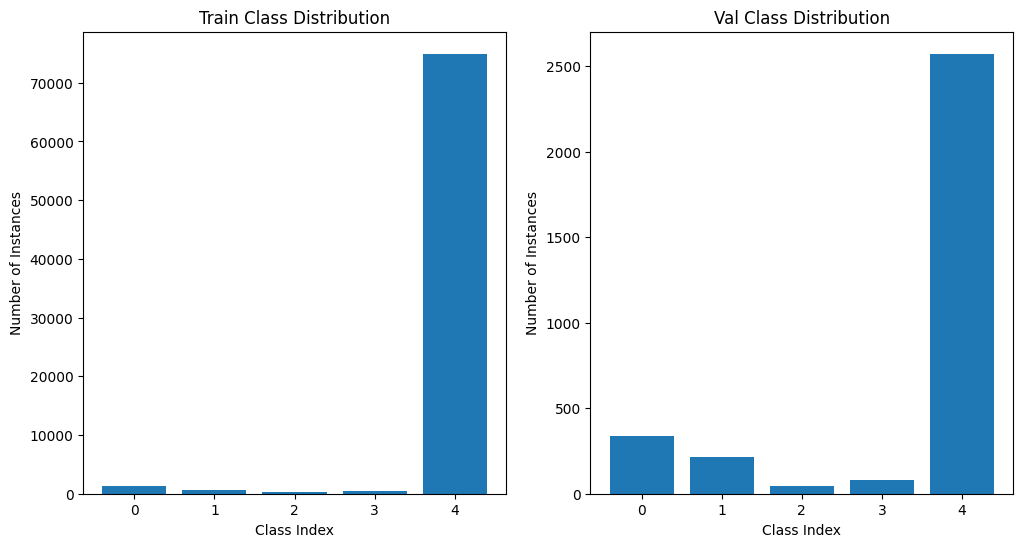

In [ ]:
def count_instances(split):
    labels_dir = combined_dataset_dir / split / "labels"
    class_counts = Counter()
    for label_file in os.listdir(labels_dir):
        with open(labels_dir / label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_idx = int(parts[0])
                    class_counts[class_idx] += 1
    return class_counts

# Log image counts
train_images = len(os.listdir(combined_dataset_dir / "train" / "images"))
val_images = len(os.listdir(combined_dataset_dir / "val" / "images"))
logger.info(f"Total train images: {train_images}")
logger.info(f"Total val images: {val_images}")

# Log class counts
train_counts = count_instances('train')
val_counts = count_instances('val')

logger.info("Train class counts:")
for cls, count in train_counts.items():
    logger.info(f"Class {cls} ({['hole', 'pole', 'stairs', 'bottle', 'rock'][cls]}): {count}")

logger.info("Val class counts:")
for cls, count in val_counts.items():
    logger.info(f"Class {cls} ({['hole', 'pole', 'stairs', 'bottle', 'rock'][cls]}): {count}")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].bar(train_counts.keys(), train_counts.values())
ax[0].set_title('Train Class Distribution')
ax[0].set_xlabel('Class Index')
ax[0].set_ylabel('Number of Instances')
ax[1].bar(val_counts.keys(), val_counts.values())
ax[1].set_title('Val Class Distribution')
ax[1].set_xlabel('Class Index')
ax[1].set_ylabel('Number of Instances')
plt.savefig(combined_dataset_dir / 'class_distribution.png')
logger.info("Class distribution saved to combined_dataset/class_distribution.png")

# balancing based on rocks (no filter)

In [ ]:
import random
from collections import Counter
import shutil
from pathlib import Path
import os
import logging

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Define paths
combined_dataset_dir = Path("/content/drive/MyDrive/EnigmaAI_temp/combined_dataset")
balanced_dataset_dir = Path("/content/drive/MyDrive/EnigmaAI_temp/balanced_dataset")

# Function to analyze a dataset split
def analyze_split(split, dataset_dir):
    labels_dir = dataset_dir / split / "labels"
    rock_only = []  # (image_name, rock_count)
    mixed = []      # image_names with rock and other classes
    no_rock = []    # image_names without rock
    N_mixed_rock = 0
    for label_file in os.listdir(labels_dir):
        with open(labels_dir / label_file, 'r') as f:
            lines = f.readlines()
        classes = set()
        rock_count = 0
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls = int(parts[0])
                if cls == 4:
                    rock_count += 1
                classes.add(cls)
        img_name = label_file.replace('.txt', '.jpg')
        if classes == {4}:
            rock_only.append((img_name, rock_count))
        elif 4 in classes:
            mixed.append(img_name)
            N_mixed_rock += rock_count
        else:
            no_rock.append(img_name)
    return rock_only, mixed, no_rock, N_mixed_rock

# Set desired number of "rock" instances
N_desired_train = 1308  # Example: matches "hole" count in train
N_desired_val = 338     # Example: matches "hole" count in val

# Step 1: Analyze training split
rock_only_train, mixed_train, no_rock_train, N_mixed_rock_train = analyze_split('train', combined_dataset_dir)
target_rock_only_train = max(0, N_desired_train - N_mixed_rock_train)

# Step 2: Sample "rock only" images for training
selected_rock_only_train = []
current_rock_count_train = 0
rock_only_train_copy = rock_only_train.copy()
while current_rock_count_train < target_rock_only_train and rock_only_train_copy:
    img, rock_count = random.choice(rock_only_train_copy)
    selected_rock_only_train.append(img)
    current_rock_count_train += rock_count
    rock_only_train_copy.remove((img, rock_count))

# Step 3: Analyze validation split
rock_only_val, mixed_val, no_rock_val, N_mixed_rock_val = analyze_split('val', combined_dataset_dir)
target_rock_only_val = max(0, N_desired_val - N_mixed_rock_val)

# Step 4: Sample "rock only" images for validation
selected_rock_only_val = []
current_rock_count_val = 0
rock_only_val_copy = rock_only_val.copy()
while current_rock_count_val < target_rock_only_val and rock_only_val_copy:
    img, rock_count = random.choice(rock_only_val_copy)
    selected_rock_only_val.append(img)
    current_rock_count_val += rock_count
    rock_only_val_copy.remove((img, rock_count))

# Step 5: Define images to keep
train_images_to_keep = no_rock_train + mixed_train + selected_rock_only_train
val_images_to_keep = no_rock_val + mixed_val + selected_rock_only_val

# Step 6: Create balanced dataset directory
balanced_dataset_dir.mkdir(parents=True, exist_ok=True)

# Step 7: Copy images and labels to new directory
for split, images_to_keep in [('train', train_images_to_keep), ('val', val_images_to_keep)]:
    split_dir = balanced_dataset_dir / split
    split_dir.mkdir(parents=True, exist_ok=True)
    (split_dir / "images").mkdir(exist_ok=True)
    (split_dir / "labels").mkdir(exist_ok=True)
    for img in images_to_keep:
        src_img = combined_dataset_dir / split / "images" / img
        src_label = combined_dataset_dir / split / "labels" / img.replace('.jpg', '.txt')
        dst_img = split_dir / "images" / img
        dst_label = split_dir / "labels" / img.replace('.jpg', '.txt')
        try:
            shutil.copy(src_img, dst_img)
            shutil.copy(src_label, dst_label)
        except FileNotFoundError as e:
            logger.error(f"Error copying {img} for {split}: {e}")

# Step 8: Copy data.yaml
shutil.copy(combined_dataset_dir / "data.yaml", balanced_dataset_dir / "data.yaml")

# Step 9: Verify the results
logger.info(f"Train: kept {len(no_rock_train)} no rock, {len(mixed_train)} mixed, {len(selected_rock_only_train)} rock only images")
logger.info(f"Val: kept {len(no_rock_val)} no rock, {len(mixed_val)} mixed, {len(selected_rock_only_val)} rock only images")
for split in ['train', 'val']:
    img_count = len(list((balanced_dataset_dir / split / "images").glob('*.jpg')))
    label_count = len(list((balanced_dataset_dir / split / "labels").glob('*.txt')))
    logger.info(f"{split}: {img_count} images, {label_count} labels")
if (balanced_dataset_dir / "data.yaml").exists():
    logger.info("data.yaml exists in balanced_dataset")
else:
    logger.warning("data.yaml not found in balanced_dataset")

2025-05-28 03:48:48,863 - INFO - Train: kept 2478 no rock, 8 mixed, 124 rock only images
2025-05-28 03:48:48,864 - INFO - Val: kept 576 no rock, 1 mixed, 28 rock only images
2025-05-28 03:48:48,954 - INFO - train: 2610 images, 2610 labels
2025-05-28 03:48:48,971 - INFO - val: 605 images, 605 labels
2025-05-28 03:48:48,972 - INFO - data.yaml exists in balanced_dataset


In [ ]:
# Recalculate and log class counts to confirm
def count_instances(split, dataset_dir):
    labels_dir = dataset_dir / split / "labels"
    class_counts = Counter()
    for label_file in os.listdir(labels_dir):
        with open(labels_dir / label_file, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                class_idx = int(parts[0])
                class_counts[class_idx] += 1
    return class_counts

train_counts_balanced = count_instances('train', balanced_dataset_dir)
val_counts_balanced = count_instances('val', balanced_dataset_dir)
logger.info("Balanced train class counts:")
for cls, count in train_counts_balanced.items():
    logger.info(f"Class {cls} ({['hole', 'pole', 'stairs', 'bottle', 'rock'][cls]}): {count}")
logger.info("Balanced val class counts:")
for cls, count in val_counts_balanced.items():
    logger.info(f"Class {cls} ({['hole', 'pole', 'stairs', 'bottle', 'rock'][cls]}): {count}")

2025-05-28 03:49:09,920 - INFO - Balanced train class counts:
2025-05-28 03:49:09,922 - INFO - Class 2 (stairs): 376
2025-05-28 03:49:09,923 - INFO - Class 3 (bottle): 507
2025-05-28 03:49:09,923 - INFO - Class 1 (pole): 602
2025-05-28 03:49:09,924 - INFO - Class 0 (hole): 1308
2025-05-28 03:49:09,925 - INFO - Class 4 (rock): 1313
2025-05-28 03:49:09,926 - INFO - Balanced val class counts:
2025-05-28 03:49:09,927 - INFO - Class 2 (stairs): 47
2025-05-28 03:49:09,928 - INFO - Class 1 (pole): 213
2025-05-28 03:49:09,929 - INFO - Class 3 (bottle): 81
2025-05-28 03:49:09,929 - INFO - Class 0 (hole): 338
2025-05-28 03:49:09,930 - INFO - Class 4 (rock): 366


# balancing based on Rocks (with filter)

In [ ]:
import random
from collections import Counter
import shutil
from pathlib import Path
import os
import logging
import cv2
import numpy as np

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Define paths
combined_dataset_dir = Path("/content/drive/MyDrive/EnigmaAI_temp/combined_dataset")
balanced_dataset_dir = Path("/content/drive/MyDrive/EnigmaAI_temp/balanced_dataset")

# Function to calculate bounding box area
def calculate_bbox_area(bbox):
    x_center, y_center, width, height = bbox
    return width * height

# Function to analyze a dataset split with quality filtering
def analyze_split_with_quality(split, dataset_dir, min_area_threshold=0.01, max_instances=5):
    labels_dir = dataset_dir / split / "labels"
    images_dir = dataset_dir / split / "images"
    rock_only = []  # (image_name, rock_count, avg_rock_area)
    mixed = []      # (image_name, rock_count, avg_rock_area)
    no_rock = []    # image_names without rock
    N_mixed_rock = 0

    for label_file in os.listdir(labels_dir):
        img_name = label_file.replace('.txt', '.jpg')
        img_path = images_dir / img_name
        if not img_path.exists():
            continue

        # Load image to get dimensions
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_height, img_width = img.shape[:2]

        with open(labels_dir / label_file, 'r') as f:
            lines = f.readlines()
        classes = set()
        rock_bboxes = []
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls = int(parts[0])
                if cls == 4:
                    # Convert normalized bbox to absolute coordinates
                    x_center = float(parts[1]) * img_width
                    y_center = float(parts[2]) * img_height
                    width = float(parts[3]) * img_width
                    height = float(parts[4]) * img_height
                    bbox = (x_center, y_center, width, height)
                    area = calculate_bbox_area(bbox)
                    rock_bboxes.append(area)
                classes.add(cls)

        if not rock_bboxes:
            no_rock.append(img_name)
            continue

        rock_count = len(rock_bboxes)
        avg_rock_area = np.mean(rock_bboxes) / (img_width * img_height)  # Normalized area

        if classes == {4}:  # Rock only
            if avg_rock_area >= min_area_threshold and rock_count <= max_instances:
                rock_only.append((img_name, rock_count, avg_rock_area))
        elif 4 in classes:  # Mixed
            if avg_rock_area >= min_area_threshold and rock_count <= max_instances:
                mixed.append((img_name, rock_count, avg_rock_area))
                N_mixed_rock += rock_count
        else:
            no_rock.append(img_name)

    return rock_only, mixed, no_rock, N_mixed_rock

# Set desired number of "rock" instances
N_desired_train = 1308
N_desired_val = 338

# Quality thresholds
min_area_threshold = 0.01  # Minimum average rock area (normalized)
max_instances = 5          # Maximum number of rock instances per image

# Step 1: Analyze training split with quality filtering
rock_only_train, mixed_train, no_rock_train, N_mixed_rock_train = analyze_split_with_quality('train', combined_dataset_dir, min_area_threshold, max_instances)
target_rock_only_train = max(0, N_desired_train - N_mixed_rock_train)

# Step 2: Sample high-quality "rock only" images for training
selected_rock_only_train = []
current_rock_count_train = 0
rock_only_train_copy = rock_only_train.copy()
while current_rock_count_train < target_rock_only_train and rock_only_train_copy:
    img, rock_count, _ = random.choice(rock_only_train_copy)
    selected_rock_only_train.append(img)
    current_rock_count_train += rock_count
    rock_only_train_copy.remove((img, rock_count, _))

# Step 3: Analyze validation split with quality filtering
rock_only_val, mixed_val, no_rock_val, N_mixed_rock_val = analyze_split_with_quality('val', combined_dataset_dir, min_area_threshold, max_instances)
target_rock_only_val = max(0, N_desired_val - N_mixed_rock_val)

# Step 4: Sample high-quality "rock only" images for validation
selected_rock_only_val = []
current_rock_count_val = 0
rock_only_val_copy = rock_only_val.copy()
while current_rock_count_val < target_rock_only_val and rock_only_val_copy:
    img, rock_count, _ = random.choice(rock_only_val_copy)
    selected_rock_only_val.append(img)
    current_rock_count_val += rock_count
    rock_only_val_copy.remove((img, rock_count, _))

# Step 5: Define images to keep
train_images_to_keep = no_rock_train + [img for img, _, _ in mixed_train] + selected_rock_only_train
val_images_to_keep = no_rock_val + [img for img, _, _ in mixed_val] + selected_rock_only_val

# Step 6: Create balanced dataset directory
balanced_dataset_dir.mkdir(parents=True, exist_ok=True)

# Step 7: Copy images and labels to new directory
for split, images_to_keep in [('train', train_images_to_keep), ('val', val_images_to_keep)]:
    split_dir = balanced_dataset_dir / split
    split_dir.mkdir(parents=True, exist_ok=True)
    (split_dir / "images").mkdir(exist_ok=True)
    (split_dir / "labels").mkdir(exist_ok=True)
    for img in images_to_keep:
        src_img = combined_dataset_dir / split / "images" / img
        src_label = combined_dataset_dir / split / "labels" / img.replace('.jpg', '.txt')
        dst_img = split_dir / "images" / img
        dst_label = split_dir / "labels" / img.replace('.jpg', '.txt')
        try:
            shutil.copy(src_img, dst_img)
            shutil.copy(src_label, dst_label)
        except FileNotFoundError as e:
            logger.error(f"Error copying {img} for {split}: {e}")

# Step 8: Copy data.yaml
shutil.copy(combined_dataset_dir / "data.yaml", balanced_dataset_dir / "data.yaml")

# Step 9: Verify the results
logger.info(f"Train: kept {len(no_rock_train)} no rock, {len(mixed_train)} mixed, {len(selected_rock_only_train)} rock only images")
logger.info(f"Val: kept {len(no_rock_val)} no rock, {len(mixed_val)} mixed, {len(selected_rock_only_val)} rock only images")
for split in ['train', 'val']:
    img_count = len(list((balanced_dataset_dir / split / "images").glob('*.jpg')))
    label_count = len(list((balanced_dataset_dir / split / "labels").glob('*.txt')))
    logger.info(f"{split}: {img_count} images, {label_count} labels")
if (balanced_dataset_dir / "data.yaml").exists():
    logger.info("data.yaml exists in balanced_dataset")
else:
    logger.warning("data.yaml not found in balanced_dataset")

2025-05-28 07:17:19,917 - INFO - Train: kept 2478 no rock, 8 mixed, 1225 rock only images
2025-05-28 07:17:19,923 - INFO - Val: kept 576 no rock, 1 mixed, 174 rock only images
2025-05-28 07:17:20,089 - INFO - train: 3711 images, 3711 labels
2025-05-28 07:17:20,128 - INFO - val: 751 images, 751 labels
2025-05-28 07:17:20,131 - INFO - data.yaml exists in balanced_dataset


In [ ]:
# Recalculate and log class counts to confirm
def count_instances(split, dataset_dir):
    labels_dir = dataset_dir / split / "labels"
    class_counts = Counter()
    for label_file in os.listdir(labels_dir):
        with open(labels_dir / label_file, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                class_idx = int(parts[0])
                class_counts[class_idx] += 1
    return class_counts

train_counts_balanced = count_instances('train', balanced_dataset_dir)
val_counts_balanced = count_instances('val', balanced_dataset_dir)
logger.info("Balanced train class counts:")
for cls, count in train_counts_balanced.items():
    logger.info(f"Class {cls} ({['hole', 'pole', 'stairs', 'bottle', 'rock'][cls]}): {count}")
logger.info("Balanced val class counts:")
for cls, count in val_counts_balanced.items():
    logger.info(f"Class {cls} ({['hole', 'pole', 'stairs', 'bottle', 'rock'][cls]}): {count}")

2025-05-28 07:18:15,587 - INFO - Balanced train class counts:
2025-05-28 07:18:15,590 - INFO - Class 2 (stairs): 376
2025-05-28 07:18:15,591 - INFO - Class 3 (bottle): 507
2025-05-28 07:18:15,592 - INFO - Class 1 (pole): 602
2025-05-28 07:18:15,593 - INFO - Class 0 (hole): 1308
2025-05-28 07:18:15,594 - INFO - Class 4 (rock): 1308
2025-05-28 07:18:15,595 - INFO - Balanced val class counts:
2025-05-28 07:18:15,596 - INFO - Class 1 (pole): 213
2025-05-28 07:18:15,597 - INFO - Class 3 (bottle): 81
2025-05-28 07:18:15,598 - INFO - Class 2 (stairs): 47
2025-05-28 07:18:15,599 - INFO - Class 0 (hole): 338
2025-05-28 07:18:15,599 - INFO - Class 4 (rock): 181
